✅ Figure successfully saved to: /Users/pro2020/projects/python/inflation_in_Nigeria/output/figures/inflation_trend_line_plot.png
✅ Figure successfully saved to: /Users/pro2020/projects/python/inflation_in_Nigeria/output/figures/inflation_trend_box_plot.png
         date  yoy_inflation_pct
60 2024-01-01              29.90
61 2024-02-01              31.70
67 2024-08-01              32.15
68 2024-09-01              32.70
62 2024-03-01              33.20
66 2024-07-01              33.40
63 2024-04-01              33.69
69 2024-10-01              33.88
64 2024-05-01              33.95
65 2024-06-01              34.19
70 2024-11-01              34.60
71 2024-12-01              34.80


<Figure size 1000x500 with 0 Axes>

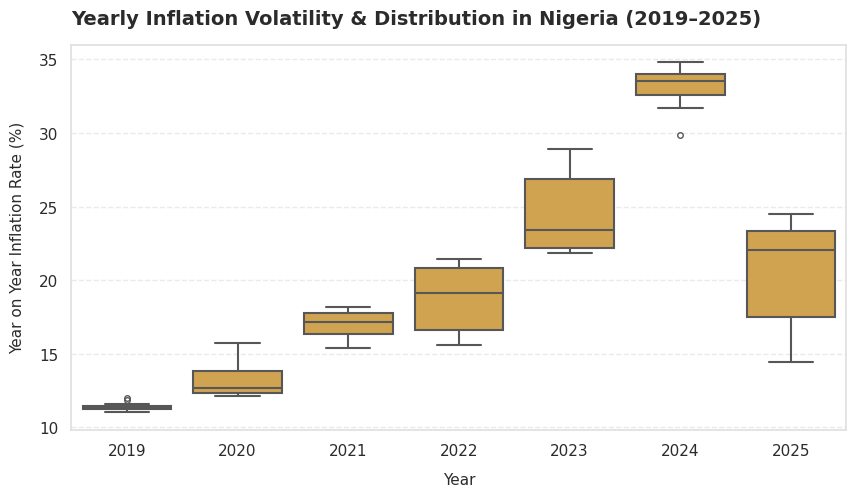

In [1]:

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import sys


PROJECT_ROOT = Path().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR, NG_DARK, NG_GREEN, NG_GOLD
from src.utils.saveFigure import saveFigure
import pandas as pd

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'text.color': NG_DARK,
    'axes.labelcolor': NG_DARK,
    'xtick.color': NG_DARK,
    'ytick.color': NG_DARK,
    'axes.edgecolor': '#E0E0E0',
    'grid.color': '#EAEAEA',
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})
    
    


# load clean csv
df = pd.read_csv(PROCESSED_DATA_DIR / 'inflation_in_nigeria_2019_2025_clean.csv', parse_dates=['date'])
df['year'] = df['date'].dt.year


# 1. How has inflation evolved in Nigeria from 2019 to 2025?
"""
    First i group the data by year, and take the min, max, mean and std of each column, this is to show the lowest and highest points
    of inflation each year, the average inflation rate and the volatility of inflation each year
"""

inflation_range = (
    df.groupby(df['date'].dt.year)['yoy_inflation_pct']
    .agg(['mean', 'min', 'max', 'std']) 
)
# save figure 
fig1 = plt.figure(figsize=(10, 5))

sns.lineplot(
    data=inflation_range,
    x=inflation_range.index,
    y='mean',
    color=NG_GREEN,
    marker='o',
    linewidth=3,
    markersize=8,
    markerfacecolor=NG_GOLD, 
    markeredgecolor=NG_GREEN
)

plt.title("Inflation Trend in Nigeria (2019–2025)")
plt.xlabel("Year")
plt.ylabel("Average Inflation (%)")

saveFigure('inflation_trend_line_plot.png', fig=fig1)

# ____ Plot the volatility by year
plt.clf()
fig2 = plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='year',
    y='yoy_inflation_pct',
    color=NG_GOLD,          # This applies your brand green to the boxes cleanly
    linewidth=1.5,
    fliersize=4              # Adjusts the size of any outlier dots if they exist
)


plt.title("Yearly Inflation Volatility & Distribution in Nigeria (2019–2025)", 
          fontsize=14, fontweight='bold', pad=15, loc='left')
plt.xlabel("Year", fontsize=11, labelpad=10)
plt.ylabel("Year on Year Inflation Rate (%)", fontsize=11, labelpad=10)
saveFigure('inflation_trend_box_plot.png', fig=fig2)

# 1. Use df (the original monthly data), filter for 2024, and sort from lowest to highest
outlier_hunter = df[df['date'].dt.year == 2024].sort_values(by='yoy_inflation_pct')


# 2. Print out the date and the inflation values to locate that ~15.5% outlier
print(outlier_hunter[['date', 'yoy_inflation_pct']])

